<a href="https://colab.research.google.com/github/AHD-12/LR_Model_with_NN/blob/main/fcc_Bike_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [53]:
dataset_cols = ["bike_count", "hour", "temp", "humidity", "wind", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional"]
bike = pd.read_csv("SeoulBikeData.csv", encoding='cp949').drop(["Date", "Holiday", "Seasons"], axis=1)

In [54]:
bike.columns = dataset_cols
bike["functional"] = (bike["functional"] == "Yes").astype(int)
bike = bike[bike["hour"] == 12]
bike = bike.drop(["hour"], axis= 1)

In [55]:
 bike.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


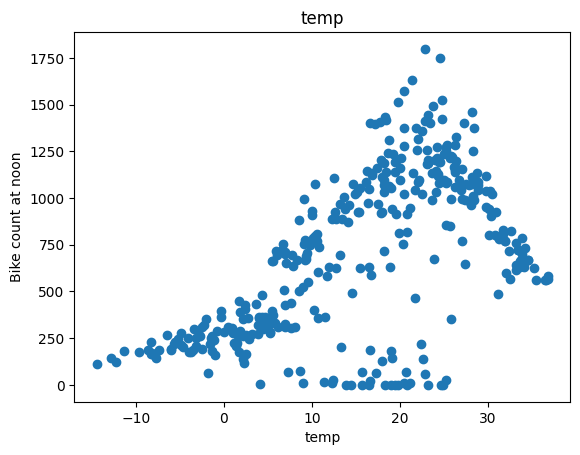

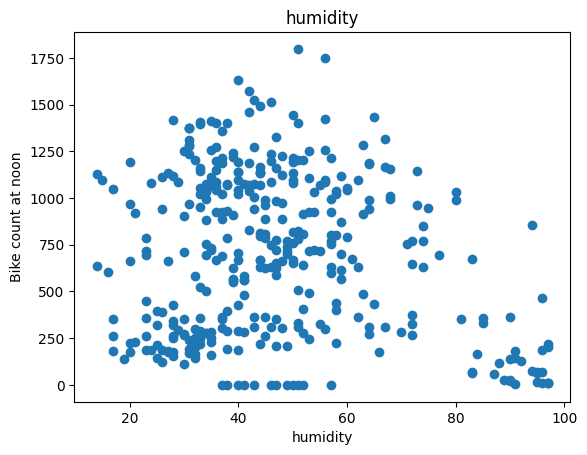

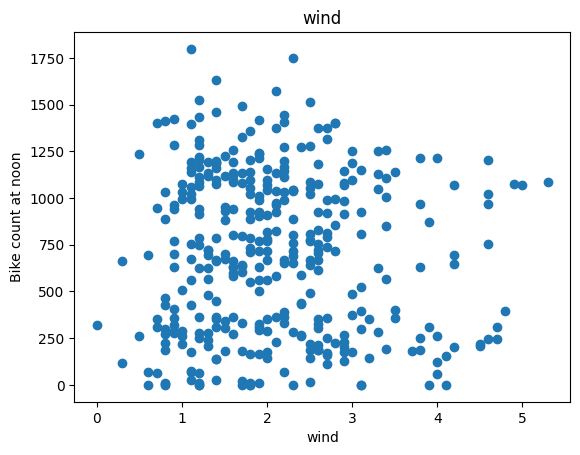

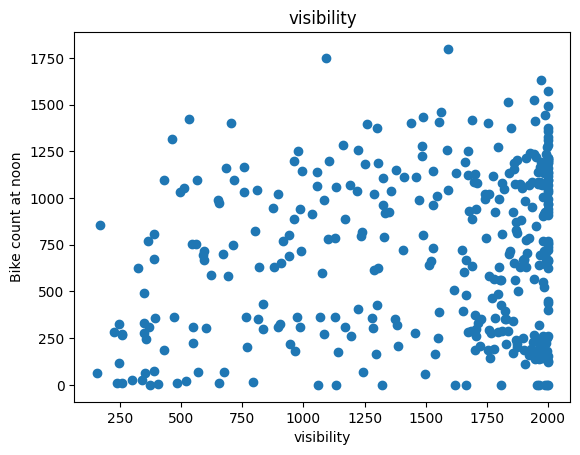

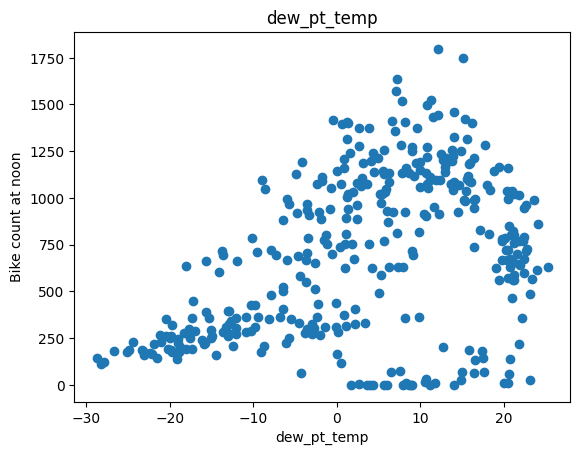

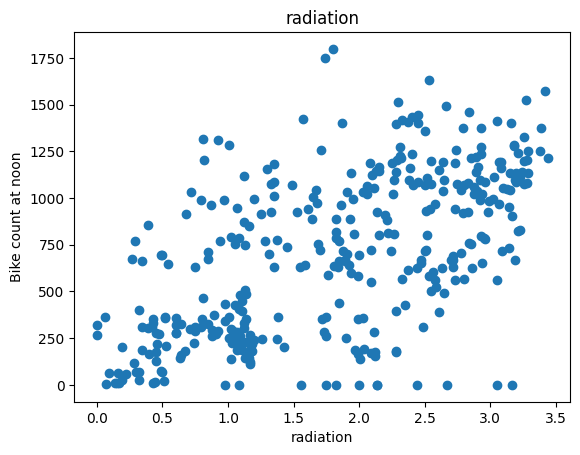

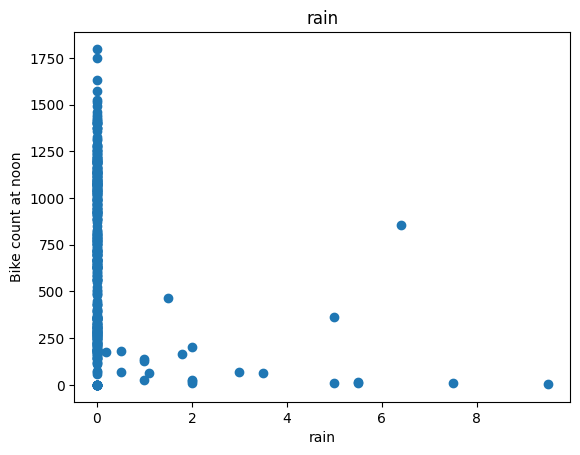

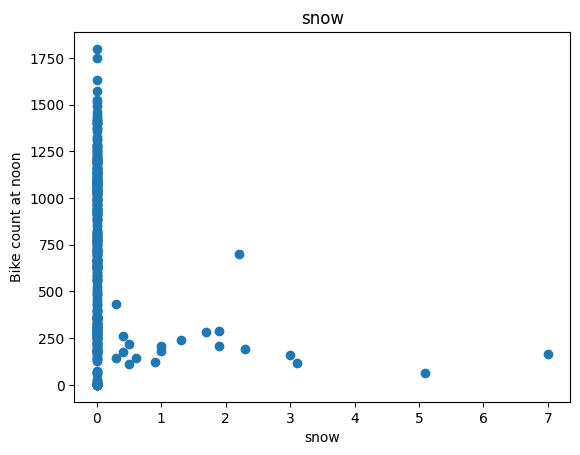

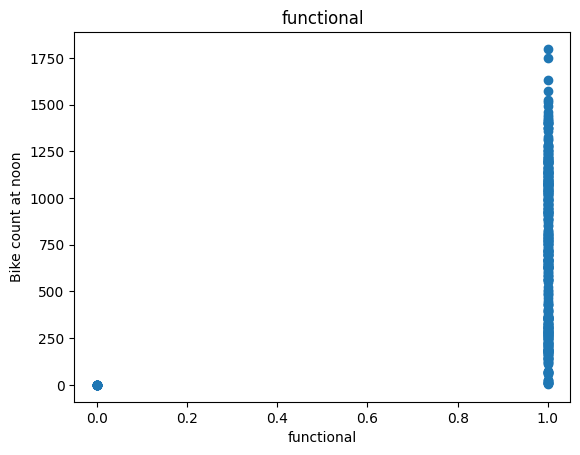

In [56]:
for label in bike.columns[1:]:
  plt.scatter(bike[label], bike["bike_count"])
  plt.title(label)
  plt.ylabel("Bike count at noon")
  plt.xlabel(label)
  plt.show()

In [57]:
bike = bike.drop(["wind", "visibility", "functional"], axis= 1)

In [58]:
bike.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


**# Train / valid / test**

In [59]:
train, val, test = np.split(bike.sample(frac= 1), [int(0.6*len(bike)), int(0.8*len(bike))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [60]:
def get_xy(dataframe, y_label, x_labels= None):
  dataframe = copy.deepcopy(dataframe)
  if x_labels is None:
    X = dataframe[[c for c in dataframe.columns if c != y_label]].values
  else:
    if len(x_labels) == 1:
      X = dataframe[x_labels[0]].values.reshape(-1, 1)
    else:
      X = dataframe[x_labels].values

  Y = dataframe[y_label].values.reshape(-1, 1)
  data = np.hstack((X,Y))

  return data, X, Y

In [61]:
_, x_train_temp, y_train_temp = get_xy(bike, "bike_count", x_labels=["temp"])
_, x_val_temp, y_val_temp = get_xy(val, "bike_count", x_labels=["temp"])
_, x_test_temp, y_test_temp = get_xy(test, "bike_count", x_labels=["temp"])

In [62]:
x_train_temp

array([[  1.7],
       [  4.3],
       [  5.8],
       [ -0.3],
       [ -2.3],
       [  2.4],
       [  3.7],
       [ -2. ],
       [  2.4],
       [  2.3],
       [ -5.2],
       [ -8.3],
       [ -6.5],
       [ -4.9],
       [ -2.5],
       [ -4.1],
       [ -4.9],
       [ -1.8],
       [ -2.5],
       [ -3.2],
       [  1.9],
       [  4.5],
       [  7. ],
       [  4.1],
       [ -1.6],
       [ -1.3],
       [ -5.5],
       [ -0.8],
       [  4.3],
       [  3.2],
       [  1.4],
       [  1.5],
       [  0.9],
       [ -3.4],
       [ -2.9],
       [ -0.3],
       [  0. ],
       [  1.1],
       [  2.7],
       [ -2.7],
       [ -5.6],
       [ -8.6],
       [ -9.6],
       [ -3.7],
       [  1.2],
       [  6.2],
       [  5.2],
       [  8.1],
       [  2.5],
       [  4.3],
       [  5.3],
       [  3.9],
       [  3.9],
       [-11.3],
       [-12.2],
       [-12.8],
       [-14.4],
       [ -7.7],
       [ -3.5],
       [ -7.3],
       [ -3.2],
       [ -1. ],
       [

In [63]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp, y_train_temp)

LinearRegression()

In [64]:
print(temp_reg.coef_, temp_reg.intercept_)

[[20.84124918]] [377.18970415]


In [65]:
temp_reg.score(x_test_temp, y_test_temp)

0.39735516917759617

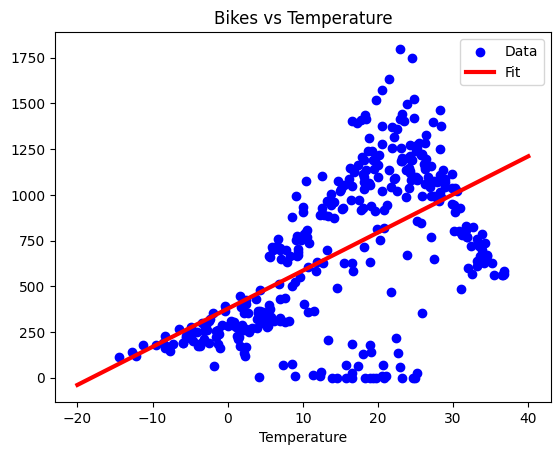

In [66]:
plt.scatter(x_train_temp, y_train_temp, label= "Data", color= "blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1, 1)), label= "Fit", color= "red", linewidth= 3)
plt.legend()
plt.title("Bikes vs Temperature")
plt.xlabel("Temperature")
plt.show()

***Multiple Linear Regression***

In [67]:
train, val, test = np.split(bike.sample(frac= 1), [int(0.6*len(bike)), int(0.8*len(bike))])
_, x_train_All, y_train_All = get_xy(bike, "bike_count", x_labels= bike.columns[1:])
_, x_val_All, y_val_All = get_xy(val, "bike_count", x_labels= bike.columns[1:])
_, x_test_All, y_test_All = get_xy(test, "bike_count", x_labels= bike.columns[1:])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [68]:
all_reg = LinearRegression()
all_reg.fit(x_train_All, y_train_All)

LinearRegression()

In [69]:
all_reg.score(x_test_All, y_test_All)

0.39976111645629553

***Regression With Neural Net***

In [70]:
def plot_loss(history):
  plt.plot(history.history["loss"], label= "loss")
  plt.plot(history.history["val_loss"], label= "val_loss")
  plt.xlabel("Epoch")
  plt.ylabel("MSE")
  plt.legend()
  plt.grid(True)
  plt.show()

In [71]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis= None)
temp_normalizer.adapt(x_train_temp.reshape(-1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(1)
])

In [73]:
temp_nn_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.1), loss= "mean_squared_error")

In [74]:
history = temp_nn_model.fit(
    x_train_temp.reshape(-1), y_train_temp,
    verbose= 0,
    epochs= 1000,
    validation_data= (x_val_temp, y_val_temp)
)

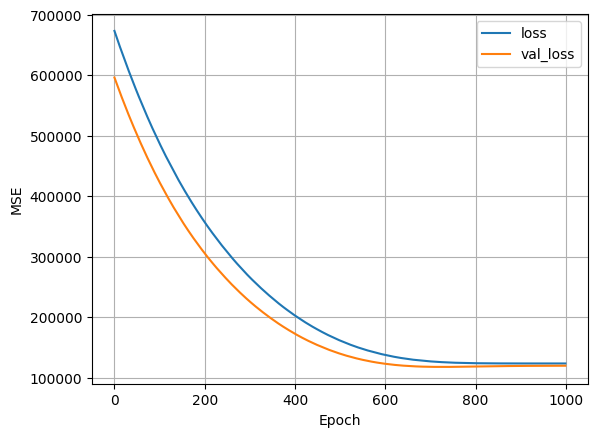

In [75]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


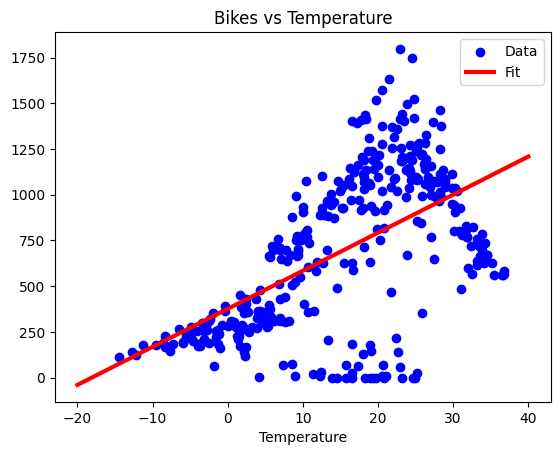

In [76]:
plt.scatter(x_train_temp, y_train_temp, label= "Data", color= "blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1, 1)), label= "Fit", color= "red", linewidth= 3)
plt.legend()
plt.title("Bikes vs Temperature")
plt.xlabel("Temperature")
plt.show()

**Neural Net**

In [77]:
nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dense(1)
])

nn_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.001), loss= "mean_squared_error")

In [78]:
history= nn_model.fit(
    x_train_temp, y_train_temp,
    validation_data= (x_val_temp, y_val_temp),
    verbose= 0,
    epochs= 100
)

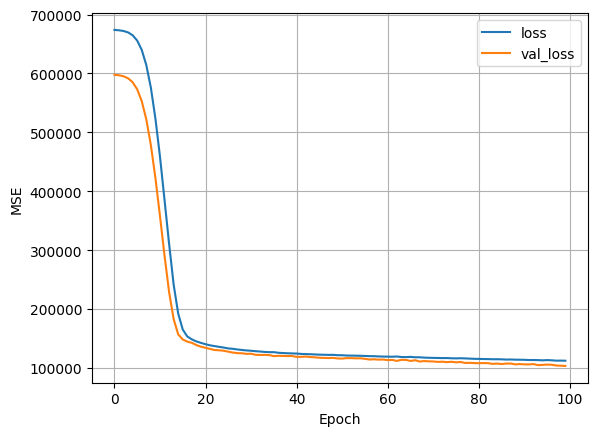

In [79]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


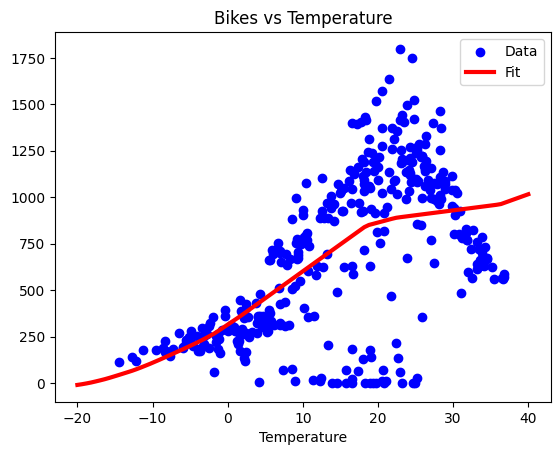

In [80]:
plt.scatter(x_train_temp, y_train_temp, label= "Data", color= "blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, nn_model.predict(np.array(x).reshape(-1, 1)), label= "Fit", color= "red", linewidth= 3)
plt.legend()
plt.title("Bikes vs Temperature")
plt.xlabel("Temperature")
plt.show()

In [81]:
all_normalizer = tf.keras.layers.Normalization(input_shape=(6,) ,axis= None)
all_normalizer.adapt(x_train_All)

In [82]:
all_nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dense(1)
])

all_nn_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate= 0.001), loss= "mean_squared_error")

In [83]:
history= all_nn_model.fit(
    x_train_All, y_train_All,
    validation_data= (x_val_All, y_val_All),
    verbose= 0,
    epochs= 100
)

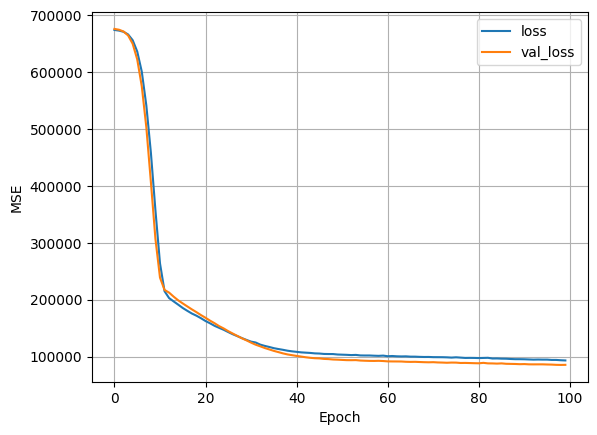

In [84]:
plot_loss(history)

In [85]:
y_pred_lr = all_reg.predict(x_test_All)
y_pred_nn = all_nn_model.predict(x_test_All)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [86]:
def MSE(y_pred, y_real):
  return(np.square(y_pred - y_real)).mean()

In [87]:
MSE(y_pred_lr, y_test_All)

np.float64(99877.54232476959)

In [88]:
MSE(y_pred_nn, y_test_All)

np.float64(108104.68084858445)

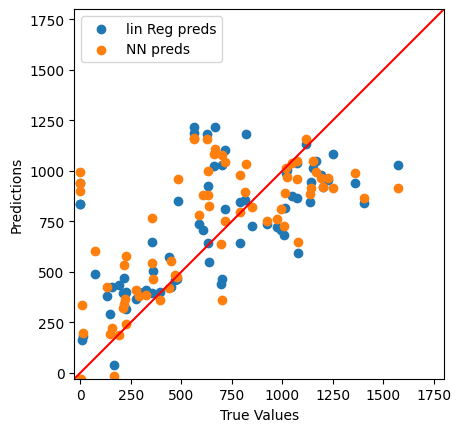

In [99]:
ax= plt.axes(aspect= "equal")
plt.scatter(y_test_All, y_pred_lr, label= "lin Reg preds")
plt.scatter(y_test_All, y_pred_nn, label= "NN preds")
plt.xlabel("True Values")
plt.ylabel("Predictions")
lims= [-30, 1800]
plt.ylim(lims)
plt.xlim(lims)
plt.legend()
_= plt.plot(lims, lims, c= "red")